# Question 1 

In [1]:
pip install --upgrade numpy scipy

Note: you may need to restart the kernel to use updated packages.


In [3]:
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np
import sys
import statsmodels.api as sm
import math

In [ ]:
strength = [160, 171, 175, 182, 184, 181, 188, 193, 195, 200] # y
caramel_percent = [10, 15, 15, 20, 20, 20, 25, 25, 28, 30] # x

In [ ]:
print(np.mean(strength))
print(np.mean(caramel_percent))

### 1(a)

In [ ]:
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.linregress.html
slope, intercept, r, p, se = stats.linregress(caramel_percent, strength) #stats.linregress(x, y)
print(f"β̂₀ (intercept) = {intercept:.4f}")
print(f"β̂₁ (slope)     = {slope:.4f}")
print(f"R²             = {r**2:.4f}")
print(f"p-value        = {p:.6f}")
print(f"Std Error β̂₁  = {se:.4f}")

#### ŷ = β̂₀ + β̂₁x = 143.824 + 1.879·x

So for every 1% increase in caramel, the simulated tensile strength increases by ~1.879 units.


### 1(b)

In [ ]:
#https://www.geeksforgeeks.org/data-science/ordinary-least-squares-ols-using-statsmodels/

x_with_const = sm.add_constant(caramel_percent) # Add a Constant Term to include an intercept term
y = strength
result = sm.OLS(y, x_with_const).fit() # fit the OLS regression model
print(result.summary())


| Factor               | Coef      | P-Value      | Interpretation             |
| -------------------- | --------- | ------------ | -------------------------- |
| Intercept            | 143.824   | 0.000        | Baseline strength          |
| Percent Caramel (β₁) | **1.879** | **2.20e-07** | **Strong Positive Effect** |


| Component               | Value         | Meaning                                |
| ------------------------| --------------| -------------------------------------- |
| Coefficient (β₁)   | 1.8786        | Magnitude. Increasing percent caramel increases simulated strength. |
| P-Value                 | 2.20e-07      | Certainty. Since p-value < 0.05 and 0.01. This effect is real, not random noise. Percent Caramel is a statistically significant factor |
| R-squared               | 0.970         | Fit. Our model explains 97.0% of the variation in simulated strength. |

Percent Caramel is a statistically significant factor. **Translation:** Higher caramel content consistently increases tensile strength — each additional 1% of caramel raises strength by ~1.879 units. The model explains 97% of the variance (R² = 0.970), showing that caramel percentage is the main factor affecting tensile strength.

### 1(c)

In [ ]:
# β1±tα/2,n−2⋅SE(β1)

alpha = 0.05

n = len(strength)
t_crit = stats.t.ppf(1.0 - 0.5 * alpha, df= n-2) # 95% CI

# slope and se declared in lingress part 1(a)
ci_low  = slope - t_crit * se 
ci_high = slope + t_crit * se

print(f"95% CI on β₁: ({ci_low:.3f}, {ci_high:.3f})")

With 95% confidence, each additional 1% caramel increases simulated strength by between about 1.61 and 2.15 units.

Because sample is small (n=10) and σ² of β₁ is unknown, we use a t-distrbution to estimate the confidence interval

### 1(d)

### 2² Full Factorial Design

#### Factors and Response

- **Factor A (Percent Caramel):** $X_a$  
- **Factor B (Cook Time):** $X_b$
- $X_c$**: interaction between A and B**
- **Response Variable (Simulated Strength):** $Y$

---

#### Factor Level Table

| Factor | Low (-1) | High (+1) |
|--------|---------|-----------|
| Percent Caramel (A) | 15% | 25% |
| Cook Time (B) | 2 hrs | 4 hrs |

There are $2^2 = 4$ runs since there are two factors with two levels each.

---

#### Model

$$
Y = \beta_0 + \beta_a X_a + \beta_b X_b + \beta_{ab} X_a X_b + \epsilon
$$

---

#### Standard Order (Design Matrix)

| Run | A (Caramel) | B (Cook Time) | C = A × B | Y |
|-----|------------|--------------|------|----|
| (1) | -1 | -1 | +1 | 170 |
| a   | +1 | -1 | -1 | 190 |
| b   | -1 | +1 | -1 | 168 |
| ab  | +1 | +1 | +1 | 196 |


# Question 2

### 2(b)

In [47]:
import numpy as np
from scipy.integrate import solve_ivp

In [48]:
# helper functions dU_dx(x, y, mu) and dU_dy(x, y, mu)
def dU_dx(x, y, mu):
    r1 = np.sqrt((x + mu)**2 + y**2)
    r2 = np.sqrt((x - (1 - mu))**2 + y**2)
    dUdx = x - (((1 - mu) * (x + mu)) / r1**3) - ((mu * (x - (1 - mu))) / r2**3)
    return dUdx

def dU_dy(x, y, mu):
    r1 = np.sqrt((x + mu)**2 + y**2)
    r2 = np.sqrt((x - (1 - mu))**2 + y**2)
    dUdy = y - (((1 - mu) * y) / r1**3) - ((mu*y) / r2**3)
    return dUdy

In [49]:
# function cr3p_derivatives
def cr3bp_derivatives(t, state, mu):
    x, y, vx, vy = state
    
    dx  = vx
    dy  = vy
    
    dvx = 2 * vy  + dU_dx(x, y, mu)
    dvy = -2 * vx + dU_dy(x, y, mu)
    
    return [dx, dy, dvx, dvy]

In [65]:
# function inputs:
mu  = 0.010                      # example mu parameter
X0  = [0.5, 0.1, 0.0, 0.5]       # example initial state format: [x, y, vx, vy]
T = 100.0                        # 100-day trajectory
time = np.linspace(0, T, 10000)  # t-eval with 100 days

# scipy.integrate.solve_ivp function call 
# simulate 100-day trajectory
sol = solve_ivp(
    cr3bp_derivatives,        # ODE function
    [0, T],                   # time span
    X0,                       # initial conditions
    args=(mu,),               # mu parameter for cr3bp_derivatives function
    method='RK45',            # same method as lab7
    t_eval=time
)

In [70]:
print("=" * 50)
print("Derivatives at t=0 (cr3bp_derivatives() returns):")
print("=" * 50)
derivs = cr3bp_derivatives(0, X0, mu)   # call the function directly (t = 0)
print(f"  dx/dt  = {derivs[0]:.6f}  (= vx)")
print(f"  dy/dt  = {derivs[1]:.6f}  (= vy)")
print(f"  dvx/dt = {derivs[2]:.6f}  (= 2*vy + dU/dx)")
print(f"  dvy/dt = {derivs[3]:.6f}  (= -2*vx + dU/dy)")

print("=" * 50)
print("Initial State:")
print("=" * 50)
print(f"  x0  = {sol.y[0, 0]:.6f}")
print(f"  y0  = {sol.y[1, 0]:.6f}")
print(f"  vx0 = {sol.y[2, 0]:.6f}")
print(f"  vy0 = {sol.y[3, 0]:.6f}")

print("=" * 50)
print("Final State:")
print("=" * 50)
print(f"  x   = {sol.y[0, -1]:.6f}")
print(f"  y   = {sol.y[1, -1]:.6f}")
print(f"  vx  = {sol.y[2, -1]:.6f}")
print(f"  vy  = {sol.y[3, -1]:.6f}")

Derivatives at t=0 (cr3bp_derivatives() returns):
  dx/dt  = 0.000000  (= vx)
  dy/dt  = 0.500000  (= vy)
  dvx/dt = -2.057642  (= 2*vy + dU/dx)
  dvy/dt = -0.613254  (= -2*vx + dU/dy)
Initial State:
  x0  = 0.500000
  y0  = 0.100000
  vx0 = 0.000000
  vy0 = 0.500000
Final State:
  x   = -0.009327
  y   = 0.000440
  vx  = -19.561018
  vy  = 29.342623


### 2(c)

In [8]:
import numpy as np
from scipy.optimize import root_scalar

mu = 0.010

# --- find L3 x-coordinate numerically: ---
# L3 is on the x-axis (y=0), on the far side of the primary
f = lambda x: dU_dx(x, 0.0, mu)
sol = root_scalar(f, bracket=[-2.0, -0.1], method='bisect')
xL3 = sol.root
yL3 = 0.0 # y = 0 (x-axis)
print("---" * 20)
print(f"L3 x-coordinate: {xL3:.10f}")
print("---" * 20)


# --- Calculate 2 × 2 matrix H ---
def evaluate_hessian(mu, xL, yL):
    x = xL
    y = yL
    h = 1e-5

    Uxx = (dU_dx(x + h, y, mu) - dU_dx(x - h, y, mu)) / (2 * h)
    Uyy = (dU_dy(x, y + h, mu) - dU_dy(x, y - h, mu)) / (2 * h)
    Uxy = (dU_dx(x, y + h, mu) - dU_dx(x, y - h, mu)) / (2 * h)
    Uyx = (dU_dy(x + h, y, mu) - dU_dy(x - h, y, mu)) / (2 * h)

    H = np.array([[Uxx, Uxy],
                  [Uyx, Uyy]])
    return H

H = evaluate_hessian(mu, xL3, yL3)
print("Hessian H:\n", H)
print("---" * 20)

# --- Construct 4 × 4 Jacobian matrix A ---

# return evaluate_hessian() into variables
Uxx, Uxy = H[0,0], H[0,1]
Uyx, Uyy = H[1,0], H[1,1]

# basically the same as the problem just filled in
A = np.array([
    [0,   0,   1,  0],
    [0,   0,   0,  1],
    [Uxx, Uxy, 0,  2],
    [Uyx, Uyy, -2, 0]
])

print("Jacobian A:\n", A)
print("---" * 20)

# --- Eigenvalues using numpy.linalg.eigvals ---
eigenvalues = np.linalg.eigvals(A)
print("Eigenvalues of A:\n", eigenvalues)
print("---" * 20)

print("Stability:")
real_parts = np.real(eigenvalues)
print(f"Real parts of eigenvalues: {real_parts}")
if np.any(real_parts > 1e-10): 
    print("CONCLUSION: L3 is UNSTABLE")
    print("Reason: at least one eigenvalue has a positive real part,")
else:
    print("CONCLUSION: L3 is STABLE")
    print("Reason: the real parts of all eigenvalues are negative")

------------------------------------------------------------
L3 x-coordinate: -1.0041666120
------------------------------------------------------------
Hessian H:
 [[ 3.01758055  0.        ]
 [ 0.         -0.00879028]]
------------------------------------------------------------
Jacobian A:
 [[ 0.          0.          1.          0.        ]
 [ 0.          0.          0.          1.        ]
 [ 3.01758055  0.          0.          2.        ]
 [ 0.         -0.00879028 -2.          0.        ]]
------------------------------------------------------------
Eigenvalues of A:
 [ 1.01156063e-16+1.00860518j  1.01156063e-16-1.00860518j
 -1.61476557e-01+0.j          1.61476557e-01+0.j        ]
------------------------------------------------------------
Stability:
Real parts of eigenvalues: [ 1.01156063e-16  1.01156063e-16 -1.61476557e-01  1.61476557e-01]
CONCLUSION: L3 is UNSTABLE
Reason: at least one eigenvalue has a positive real part,


### 2(d)

In [37]:
# L4 location given directly
mu = 0.010
x_L4 = 0.5 - mu
y_L4 = np.sqrt(3) / 2

H_L4 = evaluate_hessian(mu, x_L4, y_L4)
print("Hessian H:\n", H_L4)

Uxx_L4, Uxy_L4 = H_L4[0,0], H_L4[0,1]
Uyx_L4, Uyy_L4 = H_L4[1,0], H_L4[1,1]

A_L4 = np.array([
    [0,   0,   1,  0],
    [0,   0,   0,  1],
    [Uxx_L4, Uxy_L4, 0,  2],
    [Uyx_L4, Uyy_L4, -2, 0]
])
print("Jacobian A:\n", A_L4)

eigs_L4 = np.linalg.eigvals(A_L4)
print("L4 Eigenvalues:", eigs_L4)


Hessian H:
 [[0.75       1.27305734]
 [1.27305734 2.25      ]]
Jacobian A:
 [[ 0.          0.          1.          0.        ]
 [ 0.          0.          0.          1.        ]
 [ 0.75        1.27305734  0.          2.        ]
 [ 1.27305734  2.25       -2.          0.        ]]
L4 Eigenvalues: [ 4.23611344e-10+0.96332211j  4.23611344e-10-0.96332211j
 -4.23611112e-10+0.26834775j -4.23611112e-10-0.26834775j]


# Question 4

In [72]:
import numpy as np

def update_forest(grid):
    N = len(grid)
    new_grid = grid.copy() # synchronous update (read old, write new)
    
    directions = [(-1, 0), (1, 0), (0, -1), (0, 1)]  # N, S, W, E
    
    for i in range(N):
        for j in range(N):
            if grid[i][j] == 2: # Burning = 2 → Empty
                new_grid[i][j] = 0
                
            elif grid[i][j] == 1: # Tree = 1 

                # If any neighbor is burning (=2) → burning
                for di, dj in directions:
                    ni, nj = i + di, j + dj
                    if 0 <= ni < N and 0 <= nj < N:
                        if grid[ni][nj] == 2:
                            new_grid[i][j] = 2
                            break
                # Tree with no burning neighbor stays Tree
            # Empty stays Empty
    
    return new_grid

In [88]:
def print_grid(grid):
    symbols = {0: '.', 1: 'T', 2: 'F'}  # . = Empty, T = Tree, F = Burning
    for row in grid:
        print(' '.join(symbols[v] for v in row))
 
# NxN grid
N = 5
np.random.seed(42)
grid = (np.random.rand(N, N) < 0.7).astype(int)
grid[N//2][N//2] = 2  # ignite center
 
for t in range(8):
    print(f"Grid (t={t}):")
    print_grid(grid)
    print()
    grid = update_forest(grid)

print("T = Tree, F = Burning, . = Empty")

Grid (t=0):
T . . T T
T T . T .
T . F T T
T T T T T
T T T T T

Grid (t=1):
T . . T T
T T . T .
T . . F T
T T F T T
T T T T T

Grid (t=2):
T . . T T
T T . F .
T . . . F
T F . F T
T T F T T

Grid (t=3):
T . . F T
T T . . .
T . . . .
F . . . F
T F . F T

Grid (t=4):
T . . . F
T T . . .
F . . . .
. . . . .
F . . . F

Grid (t=5):
T . . . .
F T . . .
. . . . .
. . . . .
. . . . .

Grid (t=6):
F . . . .
. F . . .
. . . . .
. . . . .
. . . . .

Grid (t=7):
. . . . .
. . . . .
. . . . .
. . . . .
. . . . .

T = Tree, F = Burning, . = Empty


In [ ]:
import numpy as np

def update_forest(grid):
    N = grid.shape[0]
    new_grid = grid.copy()  # synchronous update (read old, write new)

    for i in range(N):
        for j in range(N):
            if grid[i, j] == 2: 
                new_grid[i, j] = 0  # 2 = Burning → Empty
                
            elif grid[i, j] == 1: # 1 = Tree
                neighbors = []
                if i > 0:     neighbors.append(grid[i-1, j])  # North
                if i < N-1:   neighbors.append(grid[i+1, j])  # South
                if j > 0:     neighbors.append(grid[i, j-1])  # West
                if j < N-1:   neighbors.append(grid[i, j+1])  # East

                # If any neighbor is burning (=2) → burning
                if 2 in neighbors:
                    new_grid[i, j] = 2
                # otherwise stays Tree

            # Empty stays Empty

    return new_grid

In [ ]:
import numpy as np

def update_forest(grid):
    N = grid.shape[0]
    new_grid = grid.copy()   # synchronous update (read old, write new)

    for i in range(N):
        for j in range(N):
            if grid[i, j] == 2:  # 2 = Burning → Empty
                new_grid[i, j] = 0

            elif grid[i, j] == 1:  # 1 = Tree
                burning_neighbor = False

                # at least one of its 4-neighbors
                if i > 0 and grid[i-1, j] == 2:      # North
                    burning_neighbor = True
                elif i < N-1 and grid[i+1, j] == 2:  # South
                    burning_neighbor = True
                elif j > 0 and grid[i, j-1] == 2:    # West
                    burning_neighbor = True
                elif j < N-1 and grid[i, j+1] == 2:  # East
                    burning_neighbor = True

                # If any neighbor is burning → burning
                if burning_neighbor:
                    new_grid[i, j] = 2

            # Empty stays Empty (no change)

    return new_grid

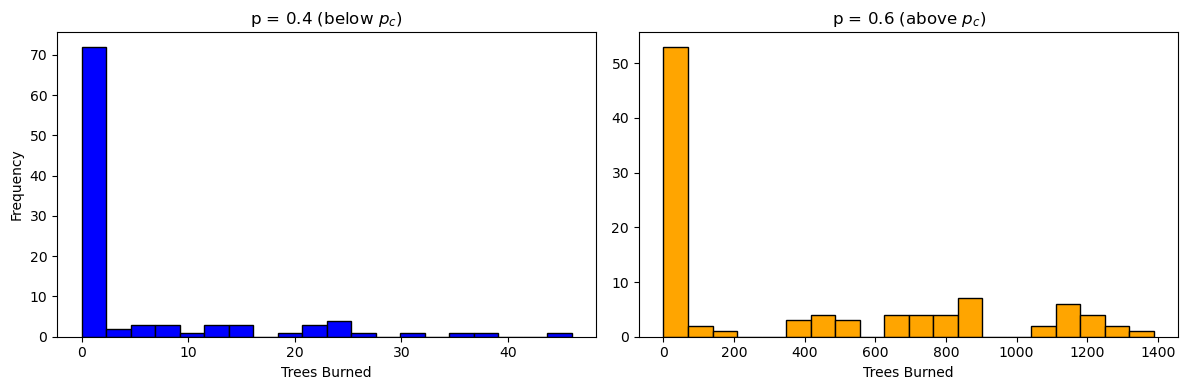

p=0.4 → mean: 5.1, std: 9.7
p=0.6 → mean: 377.9, std: 459.5


In [28]:
import numpy as np
import matplotlib.pyplot as plt

def run_simulation(N, p):
    # Initialize: each cell is Tree (1) with prob p, else Empty (0)
    grid = np.random.choice([0, 1], size=(N, N), p=[1-p, p])

    # Ignite center tree
    cx, cy = N // 2, N // 2
    if grid[cx, cy] == 1:
        grid[cx, cy] = 2
    else:
        return 0  # Center is empty, no fire starts

    trees_burned = 1  # Count the ignited center

    while True:
        new_grid = update_forest(grid)
        newly_burning = np.sum((grid != 2) & (new_grid == 2))
        trees_burned += newly_burning
        grid = new_grid
        if np.sum(grid == 2) == 0:
            break

    return trees_burned     # return total trees burned

# Run 100 simulations for each p value
N = 50
results_04 = [run_simulation(N, p=0.4) for _ in range(100)]
results_06 = [run_simulation(N, p=0.6) for _ in range(100)]

# Plot histograms
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(results_04, bins=20, color='blue', edgecolor='black')
axes[0].set_title('p = 0.4 (below $p_c$)')
axes[0].set_xlabel('Trees Burned')
axes[0].set_ylabel('Frequency')

axes[1].hist(results_06, bins=20, color='orange', edgecolor='black')
axes[1].set_title('p = 0.6 (above $p_c$)')
axes[1].set_xlabel('Trees Burned')

plt.tight_layout()
plt.show()

print(f"p=0.4 → mean: {np.mean(results_04):.1f}, std: {np.std(results_04):.1f}")
print(f"p=0.6 → mean: {np.mean(results_06):.1f}, std: {np.std(results_06):.1f}")

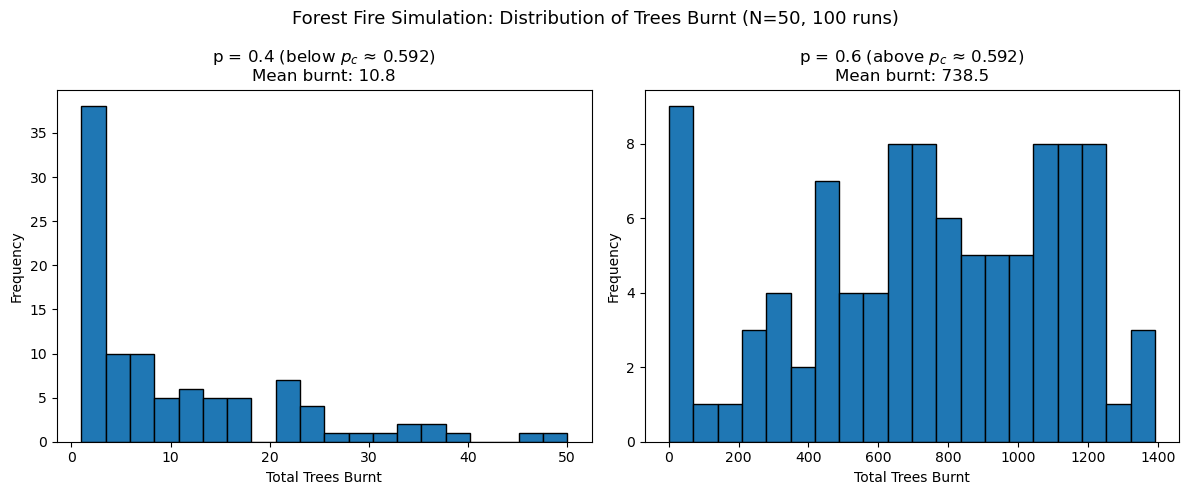

p=0.4 stats — mean: 10.8 std: 11.2
p=0.6 stats — mean: 738.5 std: 379.2
p=0.4 max burnt: 50
p=0.6 max burnt: 1392


In [32]:
import numpy as np
import matplotlib.pyplot as plt

def update_forest(grid):
    N = len(grid)
    new_grid = grid.copy()
    directions = [(-1, 0), (1, 0), (0, -1), (0, 1)]

    for i in range(N):
        for j in range(N):
            if grid[i][j] == 2:
                new_grid[i][j] = 0
            elif grid[i][j] == 1:
                for di, dj in directions:
                    ni, nj = i + di, j + dj
                    if 0 <= ni < N and 0 <= nj < N and grid[ni][nj] == 2:
                        new_grid[i][j] = 2
                        break
    return new_grid

def run_simulation(N=50, p=0.6):
    grid = (np.random.rand(N, N) < p).astype(int)   # 1=Tree, 0=Empty

    center = N // 2
    grid[center][center] = 1        # make sure center is a tree
    grid[center][center] = 2        # ignite it

    initial_trees = np.sum(grid == 1) + np.sum(grid == 2)

    while np.any(grid == 2):
        grid = update_forest(grid)

    trees_remaining = np.sum(grid == 1)
    trees_burnt = initial_trees - trees_remaining
    return trees_burnt

N = 50
results_04 = [run_simulation(N, 0.4) for _ in range(100)]
results_06 = [run_simulation(N, 0.6) for _ in range(100)]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Forest Fire Simulation: Distribution of Trees Burnt (N=50, 100 runs)', fontsize=13)

axes[0].hist(results_04, bins=20, edgecolor='black')
axes[0].set_title(f'p = 0.4 (below $p_c$ ≈ 0.592)\nMean burnt: {np.mean(results_04):.1f}')
axes[0].set_xlabel('Total Trees Burnt')
axes[0].set_ylabel('Frequency')

axes[1].hist(results_06, bins=20, edgecolor='black')
axes[1].set_title(f'p = 0.6 (above $p_c$ ≈ 0.592)\nMean burnt: {np.mean(results_06):.1f}')
axes[1].set_xlabel('Total Trees Burnt')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print("p=0.4 stats — mean:", round(np.mean(results_04), 1), "std:", round(np.std(results_04), 1))
print("p=0.6 stats — mean:", round(np.mean(results_06), 1), "std:", round(np.std(results_06), 1))
print("p=0.4 max burnt:", max(results_04))
print("p=0.6 max burnt:", max(results_06))